SmartCampus Transit: University Bus Queue Simulation and Optimization by Queue Wizards

   UNIVERSITY BUS QUEUE SIMULATION RESULTS   
Total Students Simulated : 40
Average Arrival Gap     : 5 seconds
Average Service Time    : 3 seconds
--------------------------------------------------
Average Waiting Time    : 0.99 seconds
Maximum Waiting Time    : 8.55 seconds
Maximum Queue Length    : 4 students
Server (Driver) Busy %  : 43.69%


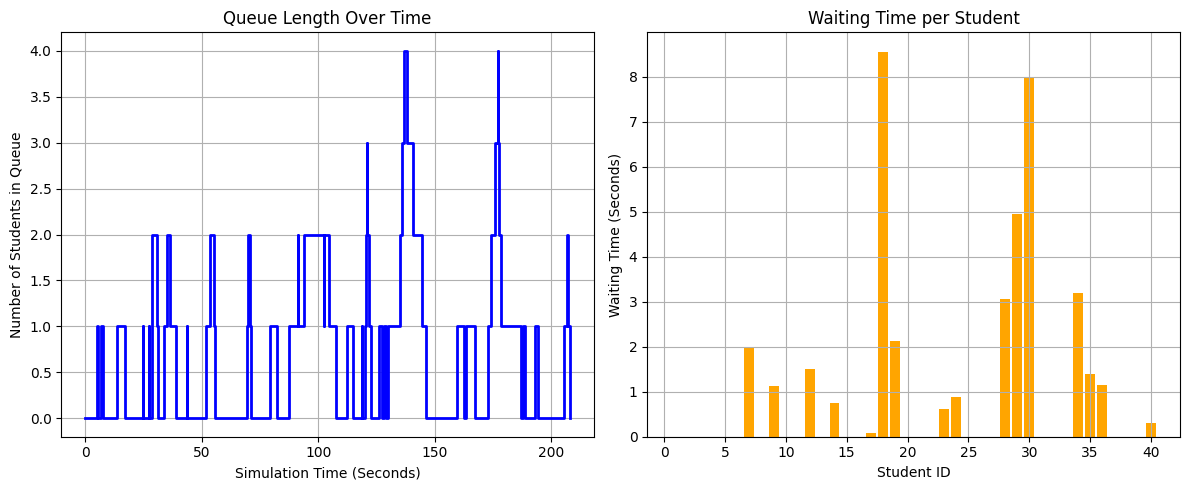

In [3]:
import random
import matplotlib.pyplot as plt

# --- ১. Config ---
NUM_STUDENTS = 40
AVG_ARRIVAL_GAP = 5
AVG_SERVICE_TIME = 3

# Fixed Random Val
random.seed(42)

# Store Data
arrival_times = []
service_times = []

# --- Random Data Genaration ---
current_time = 0
for i in range(NUM_STUDENTS):
    # Inter Arival Time
    inter_arrival = random.expovariate(1.0 / AVG_ARRIVAL_GAP)
    current_time += inter_arrival
    arrival_times.append(current_time)

    # Random Service time for student
    service_time = random.expovariate(1.0 / AVG_SERVICE_TIME)
    service_times.append(service_time)

# --- (Queue Processing) ---
waiting_times = []
service_start_times = []
service_end_times = []
server_idle_time = 0

next_available_time = 0

for i in range(NUM_STUDENTS):
    arrival = arrival_times[i]
    service = service_times[i]

    if arrival >= next_available_time:

        server_idle_time += (arrival - next_available_time)
        start_time = arrival
    else:

        start_time = next_available_time

    waiting_time = start_time - arrival
    end_time = start_time + service

    # save data
    waiting_times.append(waiting_time)
    service_start_times.append(start_time)
    service_end_times.append(end_time)

    next_available_time = end_time

# --- Result ---
total_simulation_time = next_available_time
avg_waiting_time = sum(waiting_times) / NUM_STUDENTS
max_waiting_time = max(waiting_times)
server_utilization = ((total_simulation_time - server_idle_time) / total_simulation_time) * 100

# (Queue Length Over Time)
events = []
for arr in arrival_times:
    events.append((arr, 1))
for end in service_end_times:
    events.append((end, -1))

events.sort(key=lambda x: x[0])

time_points = [0]
queue_lengths = [0]
current_queue = 0

for t, change in events:
    current_queue += change
    time_points.append(t)
    queue_lengths.append(current_queue)

max_queue_length = max(queue_lengths)

# --- OutPut ---
print("==================================================")
print("   UNIVERSITY BUS QUEUE SIMULATION RESULTS   ")
print("==================================================")
print(f"Total Students Simulated : {NUM_STUDENTS}")
print(f"Average Arrival Gap     : {AVG_ARRIVAL_GAP} seconds")
print(f"Average Service Time    : {AVG_SERVICE_TIME} seconds")
print("--------------------------------------------------")
print(f"Average Waiting Time    : {avg_waiting_time:.2f} seconds")
print(f"Maximum Waiting Time    : {max_waiting_time:.2f} seconds")
print(f"Maximum Queue Length    : {max_queue_length} students")
print(f"Server (Driver) Busy %  : {server_utilization:.2f}%")
print("==================================================")

# --- (Visualization) ---
plt.figure(figsize=(12, 5))

# change graph line size by time
plt.subplot(1, 2, 1)
plt.step(time_points, queue_lengths, where='post', color='blue', linewidth=2)
plt.title("Queue Length Over Time")
plt.xlabel("Simulation Time (Seconds)")
plt.ylabel("Number of Students in Queue")
plt.grid(True)

# student waiting
plt.subplot(1, 2, 2)
plt.bar(range(1, NUM_STUDENTS + 1), waiting_times, color='orange')
plt.title("Waiting Time per Student")
plt.xlabel("Student ID")
plt.ylabel("Waiting Time (Seconds)")
plt.grid(True)

plt.tight_layout()
plt.show()